## Incendios forestales en la región noreste de Portugal

### Problema a resolver

La finalidad de usar este dataset es poder predecir la cantidad de área que fue consumida por los incendios forestales ocurridos en el Parque Natural de Montesinho, a partir de los datos recopilados en el dataset.

Este dataset contiene los siguientes datos:

- X: Coordenada en el eje x de la ubicación del área afectada
- Y: Coordenada en el eje y de la ubicación del área afectada
- month: Mes en el que se registro el siniestro
- day: Día en el que se registro el siniestro
- FFMC: Código de Humedad del Combustible Fino (*Fine Fuel Moisture Code*), medida utilizada para evaluar la inflamabilidad de combustibles finos como las hojas y agujas de pino
- DMC: Código de Humedad Duff (*Duff Moisture Code*), indicador numérico del contenido de humedad en capas orgánicas de descomposición (humus) y material leñoso de tamaño medio
- DC: Código de Sequía (*Drought Code*), clasificación numérica del contenido de humedad de las capas orgánicas profundas, material combustible de gran tamaño como troncos y humus profundo
- ISI: Índice de Propagación Inicial (*Initial Spread Index*), medida de velocidad esperada de propagación de un incendio en base a la velocidad del viento y el *FFMC*
- temp: Temperatura en grados Celsius
- RH: Humedad Relativa
- rain: Cantidad de lluvia en milimetros
- area: Área afectada por el siniestro

In [319]:
import warnings
import sys
warnings.simplefilter("ignore")

warnings.filterwarnings("ignore") 
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)

if not sys.warnoptions:
    warnings.simplefilter("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder, FunctionTransformer
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.svm import SVR
from sklearn.compose import TransformedTargetRegressor
from sklearn.metrics import r2_score, mean_squared_error


In [320]:
df = pd.read_csv('../Dataset/forest+fires/forestfires.csv')
df

,X,Y,month,day,FFMC,DMC,DC,ISI,temp,RH,wind,rain,area
0,7,5,mar,fri,86.2,26.2,94.3,5.1,8.2,51,6.7,0.0,0.00
1,7,4,oct,tue,90.6,35.4,669.1,6.7,18.0,33,0.9,0.0,0.00
2,7,4,oct,sat,90.6,43.7,686.9,6.7,14.6,33,1.3,0.0,0.00
3,8,6,mar,fri,91.7,33.3,77.5,9.0,8.3,97,4.0,0.2,0.00
4,8,6,mar,sun,89.3,51.3,102.2,9.6,11.4,99,1.8,0.0,0.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...
512,4,3,aug,sun,81.6,56.7,665.6,1.9,27.8,32,2.7,0.0,6.44
513,2,4,aug,sun,81.6,56.7,665.6,1.9,21.9,71,5.8,0.0,54.29
514,7,4,aug,sun,81.6,56.7,665.6,1.9,21.2,70,6.7,0.0,11.16
515,1,4,aug,sat,94.4,146.0,614.7,11.3,25.6,42,4.0,0.0,0.00


### Limpieza de datos

In [321]:
print(df.shape)

(517, 13)


Podemos observar que nuestro dataset está formado por 517 filas y 13 columnas

In [322]:
df.info()
print('-'*50)
df.info(memory_usage='deep')
print('-'*50)
df.isna().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 517 entries, 0 to 516
Data columns (total 13 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   X       517 non-null    int64  
 1   Y       517 non-null    int64  
 2   month   517 non-null    object 
 3   day     517 non-null    object 
 4   FFMC    517 non-null    float64
 5   DMC     517 non-null    float64
 6   DC      517 non-null    float64
 7   ISI     517 non-null    float64
 8   temp    517 non-null    float64
 9   RH      517 non-null    int64  
 10  wind    517 non-null    float64
 11  rain    517 non-null    float64
 12  area    517 non-null    float64
dtypes: float64(8), int64(3), object(2)
memory usage: 52.6+ KB
--------------------------------------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 517 entries, 0 to 516
Data columns (total 13 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   X       517 non-null    int64  
 1   Y    

X        0
Y        0
month    0
day      0
FFMC     0
DMC      0
DC       0
ISI      0
temp     0
RH       0
wind     0
rain     0
area     0
dtype: int64

Podemos observar que nuestro dataset esta conformado por 517 entradas de datos, ninguna de las columnas contienen datos faltantes, y la mayoría de los datos son de tipo numéricos (enteros y flotantes) a excepción de dos (month y day) los cuales son de tipo object; también podemos observar que estos datos utilizan 97.1 KB de memoria

In [323]:
cols_cat = ['month', 'day']
for col in cols_cat:
    print(f'Columna {col}: {df[col].nunique()} subniveles')

Columna month: 12 subniveles
Columna day: 7 subniveles


Las columnas categóricas "month" y "day" cuentan con más de un subnivel y por lo tanto no serán eliminadas

In [324]:
df.describe()

,X,Y,FFMC,DMC,DC,ISI,temp,RH,wind,rain,area
count,517.000000,517.000000,517.000000,517.000000,517.000000,517.000000,517.000000,517.000000,517.000000,517.000000,517.000000
mean,4.669246,4.299807,90.644681,110.872340,547.940039,9.021663,18.889168,44.288201,4.017602,0.021663,12.847292
std,2.313778,1.229900,5.520111,64.046482,248.066192,4.559477,5.806625,16.317469,1.791653,0.295959,63.655818
min,1.000000,2.000000,18.700000,1.100000,7.900000,0.000000,2.200000,15.000000,0.400000,0.000000,0.000000
25%,3.000000,4.000000,90.200000,68.600000,437.700000,6.500000,15.500000,33.000000,2.700000,0.000000,0.000000
50%,4.000000,4.000000,91.600000,108.300000,664.200000,8.400000,19.300000,42.000000,4.000000,0.000000,0.520000
75%,7.000000,5.000000,92.900000,142.400000,713.900000,10.800000,22.800000,53.000000,4.900000,0.000000,6.570000
max,9.000000,9.000000,96.200000,291.300000,860.600000,56.100000,33.300000,100.000000,9.400000,6.400000,1090.840000


Las columnas que contienen datos numéricos cuentan con una desviación estándar mayor a cero, no se eliminara ninguna columna

In [325]:
print(f'Tamaño del set antes de eliminar las filas repetidas: {df.shape}')
df.drop_duplicates(inplace = True)
print(f'Tamaño del set después de eliminar las filas repetidas: {df.shape}')

Tamaño del set antes de eliminar las filas repetidas: (517, 13)
Tamaño del set después de eliminar las filas repetidas: (513, 13)


Nuestro dataset contaba con 4 filas repetidas, las cuales fueron eliminadas del mismo

In [326]:
def calcular_iqr(data):
    #Calcular cuartiles 1 y 3
    qs = data.quantile([0.25, 0.75])

    #Calcular IQR
    iqr = qs[0.75] - qs[0.25]
    return iqr, qs[0.25], qs[0.75]

Con ayuda de la función `calcular_iqr(data)` vamos a observar si nuestras variables numéricas cuentan con valores extremos (outliers)

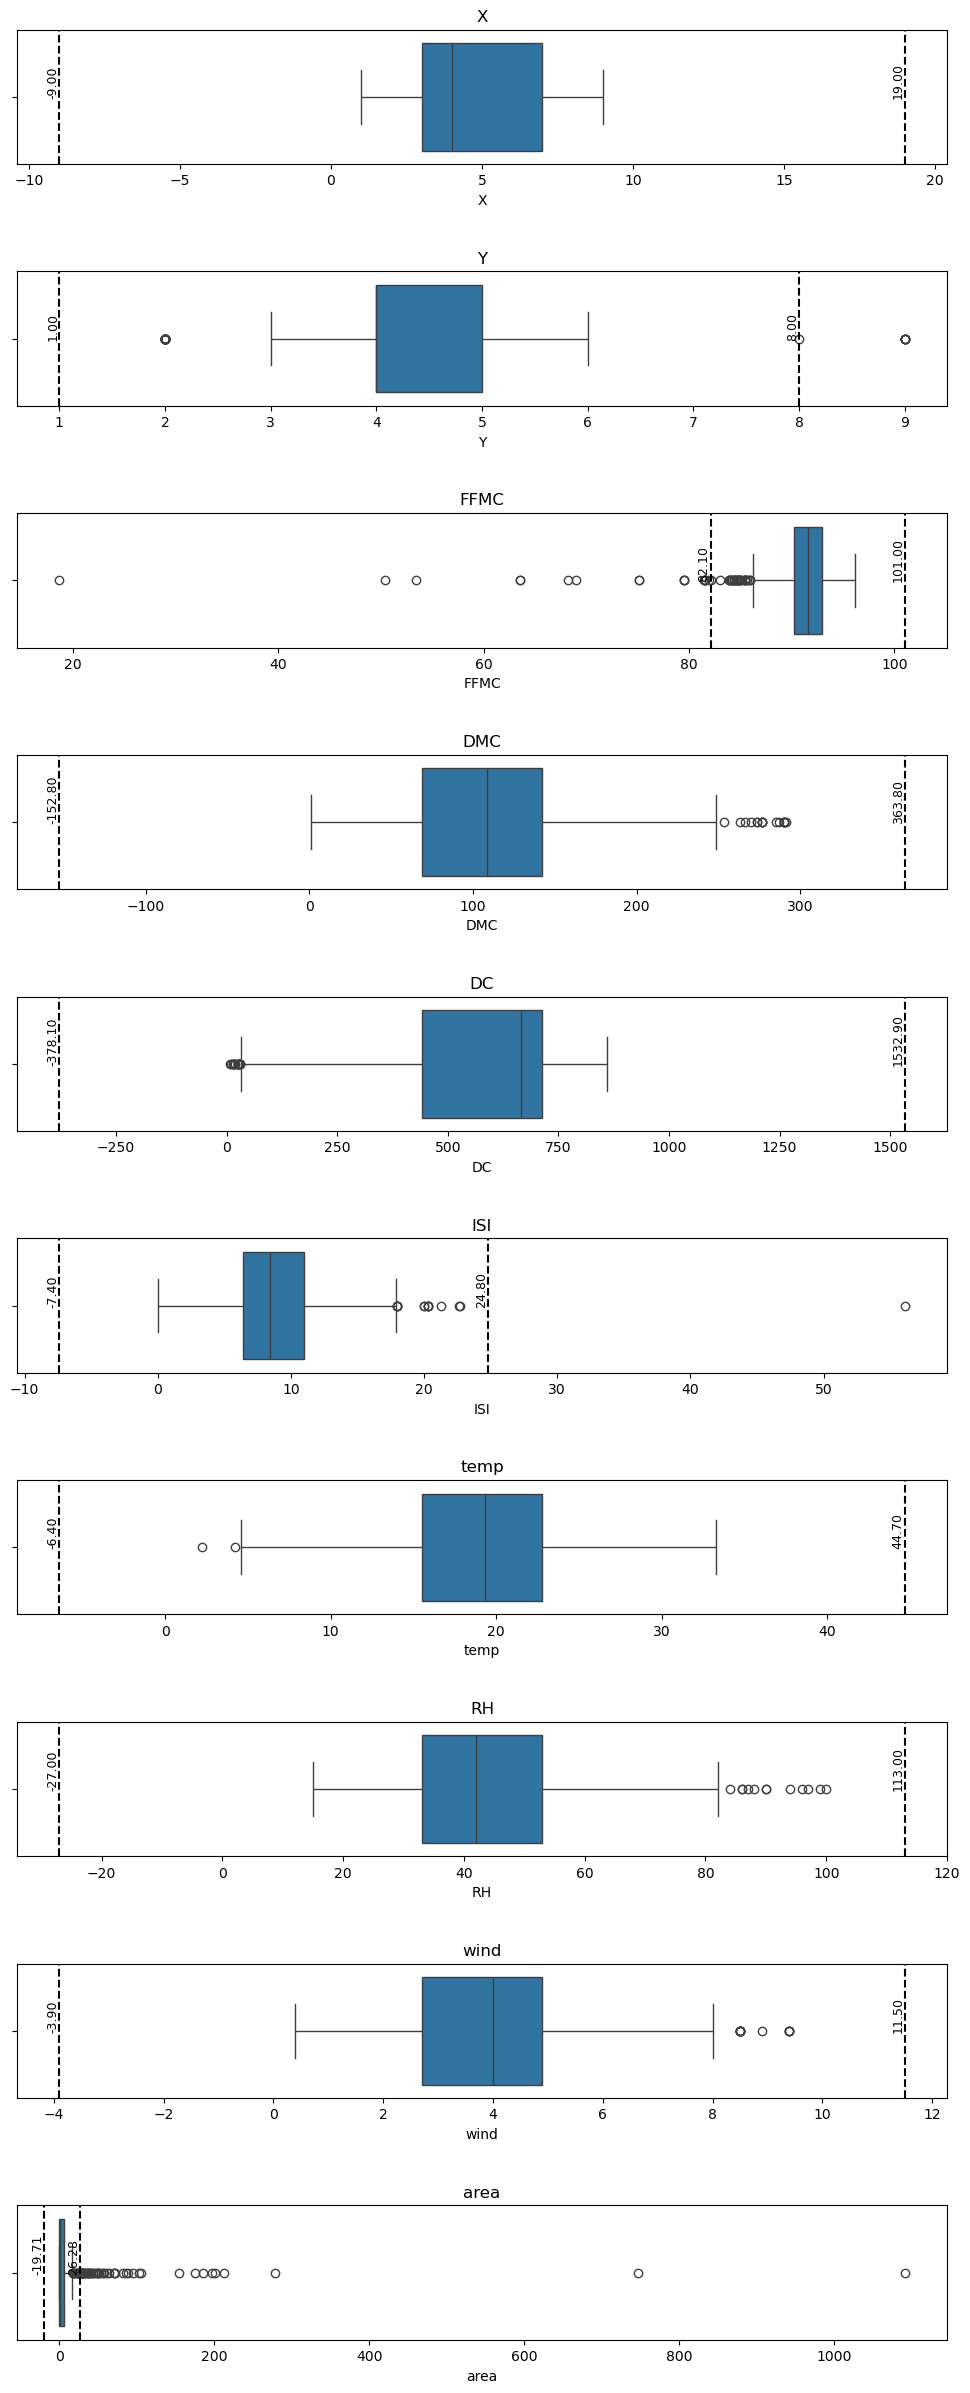

In [327]:
cols_num = ['X', 'Y', 'FFMC', 'DMC', 'DC', 'ISI', 'temp', 'RH', 'wind', 'area']

fig, ax = plt.subplots(nrows = 10, ncols=1, figsize=(12,30))
fig.subplots_adjust(hspace = 0.8)

for i, col in enumerate(cols_num):
    IQR, Q1, Q3 = calcular_iqr(df[col])
    lim_inf = (Q1-(3*IQR))
    lim_sup = (Q3+(3*IQR))
    sns.boxplot(x=col, data = df, ax = ax[i])
    ax[i].axvline(lim_inf, color = 'black', linestyle='--')
    ax[i].axvline(lim_sup, color = 'black', linestyle='--')
    ax[i].text(lim_inf, 0.01, f'{lim_inf:.2f}', rotation=90, color='black', va='bottom', ha='right', fontsize=9)
    ax[i].text(lim_sup, 0.01, f'{lim_sup:.2f}', rotation=90, color='black', va='bottom', ha='right', fontsize=9)

    ax[i].set_title(col)

Observaciones:

- La coordenada en Y tiene valores extremos, sin embargo teniendo en cuenta que solo es una referencia geográfica, no es necesario eliminarlos
- El FFMC tiene valores extremos que son menores al límite inferior, es decir $FFMC \leq 82.1$
- El DMC, DC, temp, RH, wind a pesar de que cuenta con valores extremos, aún se encuentran dentro de los límites calculados con ayuda del IQR
- El ISI cuenta con un valor extremo muy alto, el cual es mayor al límite superior calculado, aproximadamente este valor es mayor a 50, lo cual es necesario eliminarlo
- El área cuenta con valores extremos mayores al límite superior calculado. SIn embargo, para no afectar al modelo, su normalización se realizará más adelante

In [328]:
print(f'Tamaño del set antes de eliminar registros de Y: {df.shape}')
df = df[df['Y']<8]
print(f'Tamaño del set despues de eliminar registros de Y: {df.shape}')

Tamaño del set antes de eliminar registros de Y: (513, 13)
Tamaño del set despues de eliminar registros de Y: (506, 13)


Eliminamos todos los registros que se encontraban con coordenadas en Y mayores a 8, y con esto eliminamos 7 filas que cumplían con esa condición

In [329]:
print(f'Tamaño del set antes de eliminar registros de FFMC: {df.shape}')
df = df[df['FFMC']>=83.1]
print(f'Tamaño del set despues de eliminar registros de FFMC: {df.shape}')

Tamaño del set antes de eliminar registros de FFMC: (506, 13)
Tamaño del set despues de eliminar registros de FFMC: (485, 13)


Eliminamos todos los registros que se encontraban con un valor de FFMC menores a 82.1, y con esto eliminamos 19 filas que cumplían con esa condición

In [330]:
print(f'Tamaño del set antes de eliminar registros de ISI: {df.shape}')
df = df[df['ISI']<24]
print(f'Tamaño del set despues de eliminar registros de ISI: {df.shape}')

Tamaño del set antes de eliminar registros de ISI: (485, 13)
Tamaño del set despues de eliminar registros de ISI: (484, 13)


Eliminamos todos los registros que se encontraban con un valor de ISI mayores a 24, y con esto eliminamos una fila que cumplían con esa condición

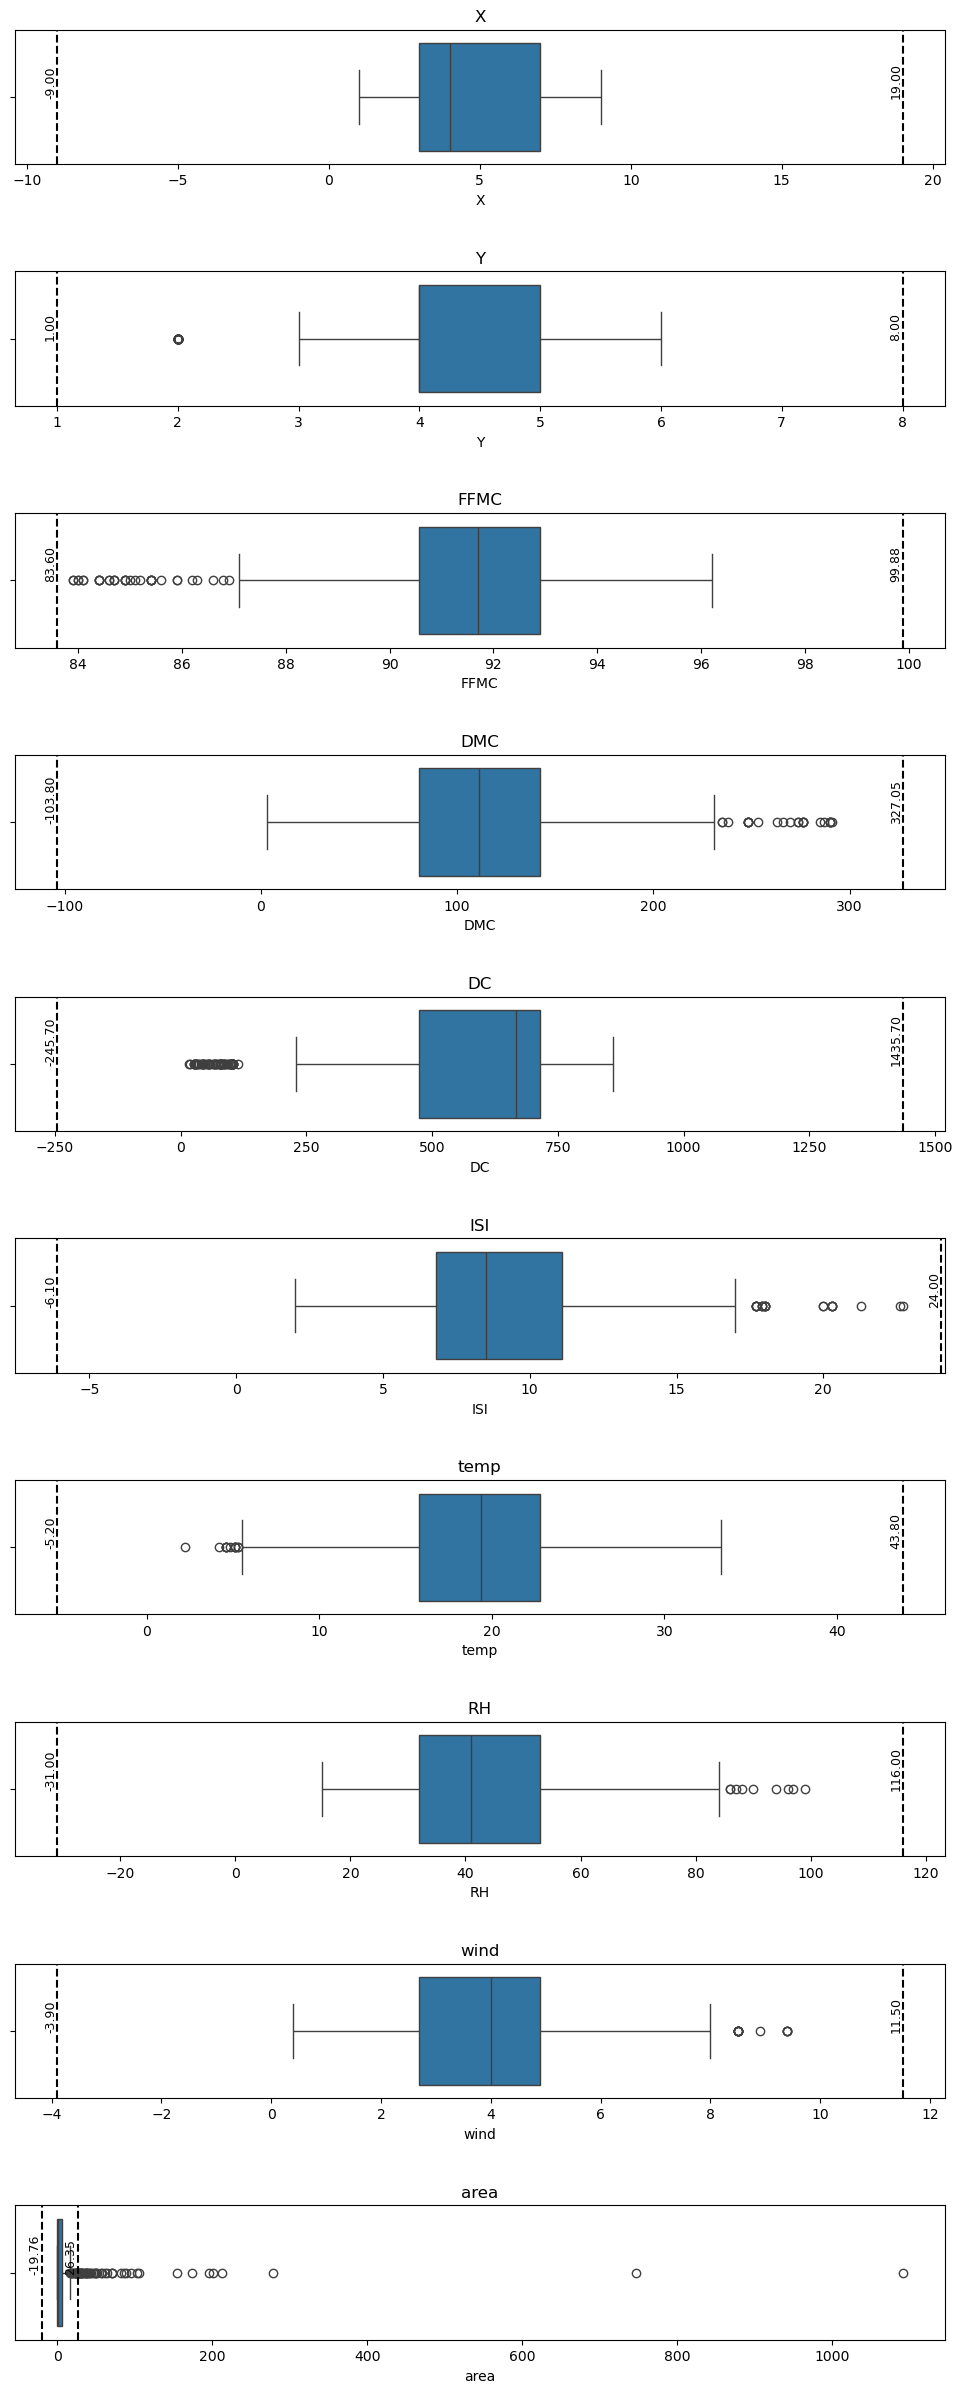

In [331]:
cols_num = ['X', 'Y', 'FFMC', 'DMC', 'DC', 'ISI', 'temp', 'RH', 'wind', 'area']

fig, ax = plt.subplots(nrows = 10, ncols=1, figsize=(12,30))
fig.subplots_adjust(hspace = 0.8)

for i, col in enumerate(cols_num):
    IQR, Q1, Q3 = calcular_iqr(df[col])
    lim_inf = (Q1-(3*IQR))
    lim_sup = (Q3+(3*IQR))
    sns.boxplot(x=col, data = df, ax = ax[i])
    ax[i].axvline(lim_inf, color = 'black', linestyle='--')
    ax[i].axvline(lim_sup, color = 'black', linestyle='--')
    ax[i].text(lim_inf, 0.01, f'{lim_inf:.2f}', rotation=90, color='black', va='bottom', ha='right', fontsize=9)
    ax[i].text(lim_sup, 0.01, f'{lim_sup:.2f}', rotation=90, color='black', va='bottom', ha='right', fontsize=9)

    ax[i].set_title(col)

Con ayuda de la visualización de las gráficas de los boxplots notamos que los valores outliers que se encuentran dentro de los rangos intercuartiles mínimo y máximo, es decir los bigotes, ya no encontramos datos fuera de los mismos.

In [332]:
ruta = './dataset_forestfires_clean.csv'
df.to_csv(ruta, index=False)

Guardamos el dataset que contiene los datos normalizados y limpios

### Modelo SVM

El modelo SVM (*Support Vector Machine*) es el que vamos a utilizar para nuestras predicciones debido a que nuestras variables "temp", "RH", "wind", "ISI" tienen una interacción que es compleja al relacionarla con la variable "area" y teniendo en cuenta esto, el SVM ayuda a poder hacer predicciones de variables no lineales. También otra cosa que beneficia el uso de este modelo es el hecho de que el área quemada que se encuentra en nuestro dataset fue generada por incendios pequeños, razón por la que se normalizaron los datos de esta columna anteriormente, e incluso con esta transformación obtenemos outliers, sin embargo el SVM se enfoca en encontrar un margen donde la mayor parte de nuestros datos se logren ajustar a una línea con un margen de error controlado

In [333]:
col_objetivo = 'area'

if col_predictoria in cols_num:
    cols_num.remove(col_objetivo)

Separamos la columna que contiene los valores que tenemos como objetivo de las columnas que contienen datos numéricos

In [334]:
X = df[cols_num + cols_cat].copy()
y = df[col_objetivo].copy()

Definimos nuestras variables predictorias, las cuales se encuentran en X, y la variable objetivo, en este caso es area pero lo vamos a almacenar en y

In [335]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

Separamos nuestros datos en conjuntos que vamos a utilizar para el entrenamiento y la prueba de nuestro modelo para posteriormente evaluarlo

In [336]:
num_conv = Pipeline(steps=[
    ('scaler', StandardScaler())
])

cat_conv = Pipeline(steps=[
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocesador = ColumnTransformer(transformers=[
    ('num', num_conv, cols_num),
    ('cat', cat_conv, cols_cat)
], remainder='drop')

Realizamos los convertidores para nuestros datos numéricos utilizando la normalización Z-score, y los datos categóricos con la codificación One-Hot, y aplicamos esas transformaciones a las columnas correspondientes y las colocamos en la variable "preprocesador"

In [337]:
obj_conv = Pipeline([
    ('log', FunctionTransformer(np.log1p, validate=True)),
    ('scale', StandardScaler())
])

Realizamos el convertidor para nuestra variable objetivo, esto debido a que esta variable ("area") tiene que normalizarse usando $\ln(x+1)$

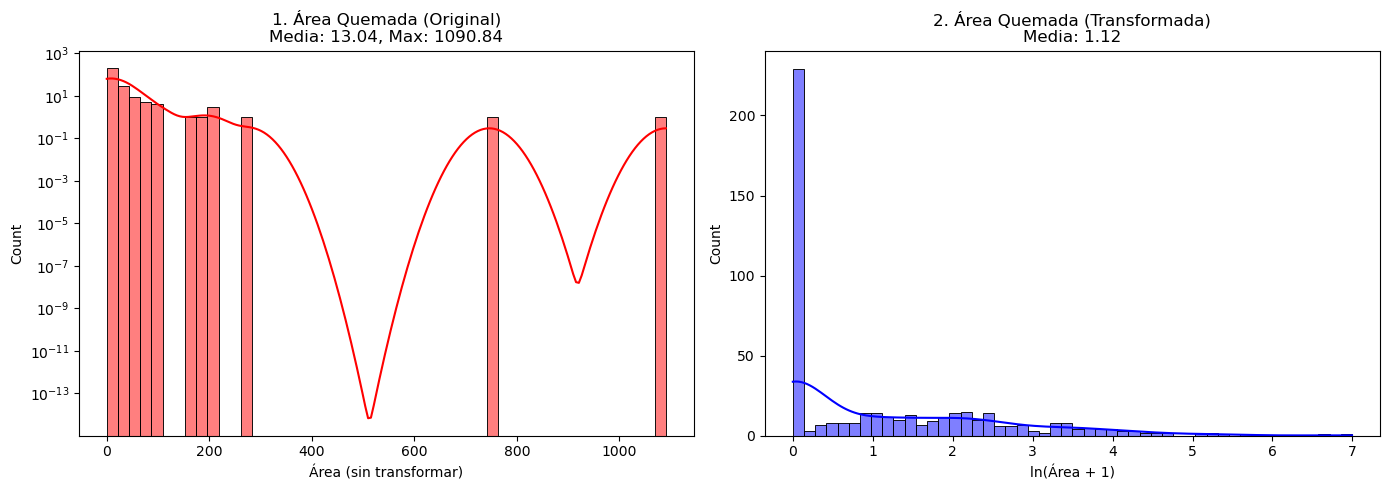

In [338]:
y_ln = np.log1p(y)

plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
sns.histplot(y[y > 0], bins=50, kde=True, color='red')
plt.title(f'1. Área Quemada (Original)\nMedia: {y.mean():.2f}, Max: {y.max():.2f}')
plt.xlabel('Área (sin transformar)')
plt.yscale('log')

plt.subplot(1, 2, 2)
sns.histplot(y_ln, bins=50, kde=True, color='blue')
plt.title(f'2. Área Quemada (Transformada)\nMedia: {y_ln.mean():.2f}')
plt.xlabel('ln(Área + 1)')

plt.tight_layout()
plt.show()


Con estas gráficas podemos hacer una comparación respecto a la distribución que tenían los datos de "area" antes y después de ser normalizada, como podemos notar, a pesar de que se realizó la transformación seguimos teniendo valores outliers, pero el modelo *SVM* es robusto respecto a los valores outliers. A pesar del valor outlier que obtenemos con la transformación, podemos notar que la distribución está más cercana a ser una normal a comparación de los valores originales

In [339]:
svr = SVR(kernel='rbf')

pipeline = Pipeline(steps=[
    ('preproc', preprocesador),
    ('svr', svr)
])

ttr = TransformedTargetRegressor(
    regressor=pipeline,
    transformer=obj_conv,
    check_inverse=False
)

Definimos el modelo SVR utilizando *Radial Basis Function*, el cual nos ayuda a poder capturar las relaciones no lineales que existen entre nuestras variables, transformamos nuestros datos con ayuda de "preprocesador", y envíamos estos datos al modelo para entrenarlo; usamos el conversor de nuestra variable objetivo, el cual fue definido anteriormente, y también calcula el inverso de esta variable, en este caso es el inverso de $\ln (x+1)$

In [340]:
param_grid = {
    'regressor__svr__C': [10, 100],
    'regressor__svr__gamma': ['scale', 0.1],
    'regressor__svr__epsilon': [0.1, 0.5]
}

Definimos una grilla de los hiperparámetros que queremos utilizar, esto con la finalidad de probar todas las combinaciones posibles de los valores para cada uno de ellos con el objetivo de encontrar la combinación que proporcione un mejor desempeño para nuestro modelo

In [341]:
gscv = GridSearchCV(
    ttr,
    param_grid,
    cv=3,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1,
    verbose=0
)

Realizamos la búsqueda de los hiperparámetros que podemos utilizar para nuestro modelo

In [342]:
gscv.fit(X_train, y_train)

print("\n--- Resultados de la Optimización ---")
print("Mejores parámetros:", gscv.best_params_)


--- Resultados de la Optimización ---
Mejores parámetros: {'regressor__svr__C': 10, 'regressor__svr__epsilon': 0.5, 'regressor__svr__gamma': 0.1}


Entrenamos nuestro modelo con los datos de entrenamiento

In [343]:
best_model = gscv.best_estimator_
y_pred = best_model.predict(X_test)

# Calcular RMSE (Raíz del Error Cuadrático Medio)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("Evaluación Final del SVR")
print(f"Test R² (escala original): {r2:.4f}")
print(f"Test RMSE (escala original): {rmse:.4f}")

Evaluación Final del SVR
Test R² (escala original): -0.0309
Test RMSE (escala original): 115.9594


Tomamos el mejor modelo posible obtenido de `GridSearchCV`, hacemos las predicciones con los datos de prueba que teníamos anteriormente, y calculamos la raíz del error cuadrático medio (RMSE) al igual que el coeficiente de determinación ($R^2$), esto nos va a ayudar a evaluar el desempeño que tiene nuestro modelo en datos que no se vieron durante el entrenamiento

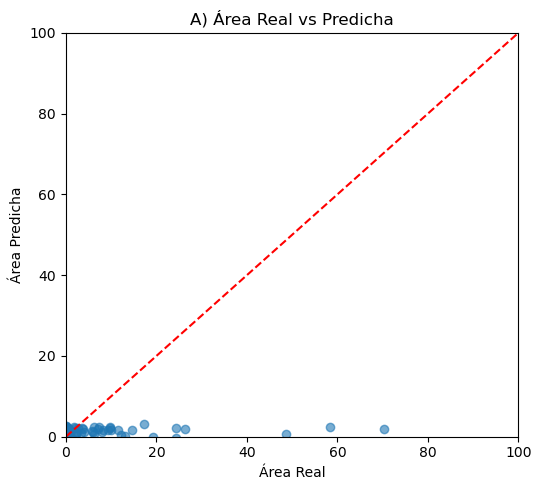

In [348]:
residuals = y_test - y_pred

plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.scatter(y_test, y_pred, alpha=0.6)

plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--', label='Predicción Ideal')
plt.xlabel('Área Real')
plt.ylabel('Área Predicha')
plt.title('A) Área Real vs Predicha')
plt.xlim(0, 100)
plt.ylim(0, 100)

plt.tight_layout()
plt.show()

Con está grafica notamos que mientras más pequeña sea el área real tiene una mejor precisión para hacer una predicción, sin embargo a medida que el área real aumenta también aumenta la impresición de la predicción realizada

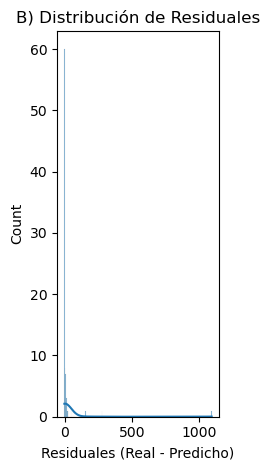

In [349]:
plt.subplot(1, 3, 2)
sns.histplot(residuals, kde=True)
plt.title('B) Distribución de Residuales')
plt.xlabel('Residuales (Real - Predicho)')

plt.tight_layout()
plt.show()

Con esta gráfica observamos que los valores residuales no siguen una distribución normal a pesar de que se realizo la normalización de los datos del área con ayuda de la función $\ln (x+1)$

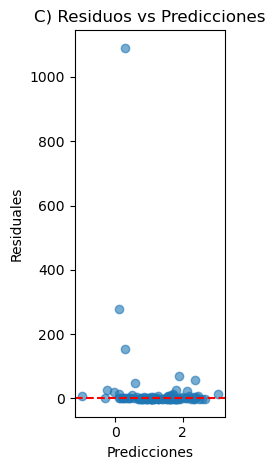

In [350]:
plt.subplot(1, 3, 3)
plt.scatter(y_pred, residuals, alpha=0.6)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel('Predicciones')
plt.ylabel('Residuales')
plt.title('C) Residuos vs Predicciones')

plt.tight_layout()
plt.show()

Notamos que la mayoría de los valores residuales se encuentran con una valor aproximado a cero, lo cual nos indica que la media de estos valores esta cercana a cero y por lo tanto el modelo no cuenta con un sesgo general

In [347]:
cv_scores = cross_val_score(best_model, X, y, cv=5, scoring='r2', n_jobs=-1)
print("\nValidación cruzada (R² en 5 folds):", cv_scores)
print("Promedio R² (CV):", np.mean(cv_scores))


Validación cruzada (R² en 5 folds): [ 0.         -0.25176182 -0.08467194 -0.15853569 -0.04249008]
Promedio R² (CV): -0.10749190569637448


Teniendo en cuenta que un valor de $R^2 = 1$ implica que el modelo esta funcionando de la mejor forma posible, en nuestro caso al haber obtenido un valor negativo implica que el modelo tiene un rendimiento bastante pobre, y por lo tanto las predicciones que se están realizando son peores si lo comparamos con usar la media de los datos 

### Conclusiones

Al haber analizado todo el dataset podemos notar lo siguiente:
- El FFMC contaba con valores outliers con valores bastante bajos y dispersos, ya que se encontraban bastante separados de los datos que se encontraron dentro del rango intercuartil, estos son valores atípicos ya que es muy complicado encontrar índices demasiado bajos en cuanto a la inflamabilidad de combustibles finos
- Los datos del área afectada o consumida por los incendios forestales eran demasiado complicado de interpretar debido a que a pesar de que en la gráfica de boxplot tenían valores relativamente bajos, había una gran cantidad de datos que quedaron completamente fuera del rango intercuartil máximo, y al analizar su desviación estándar podemos concluir que eran datos demasiado aleatorizados por así decirlo, y la mejor manera para poder normalizar esto era usando la normalización logarítmica, sin embargo, al realizar el modelo *SVM* notamos que a pesar de que se logró conseguir una distribución más cercana a la normal, el modelo *SVM* termino teniendo un desempeño bastante pobre debido a esto.
- Al realizar el modelo *SVM* podemos concluir que con la información que tiene este dataset, nos ayuda bastante a poder predecir la magnitud que hay en los incendios que ocupan un área relativamente pequeña, sin embargo al momento de querer hacer predicciones para incendios con áreas demasiado grandes no tiene una precisión muy alta, de hecho es demasiado pobre el nivel de predicción, mientras más grande sea el área del incendio la precisión de este modelo disminuye drásticamente